In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("KAKAO_REST_API_KEY"))

73923fe6c9aff51e1c382ad85842e6ce


In [4]:
# 테스트용 초기 state 만들기
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [5]:
# [노드] preprocess_input
# 사용자 입력 전처리 (변수값 매핑 + 키워드 및 반경 설정)
from nodes.preprocess_input import preprocess_input

preprocess_result = preprocess_input(initial_state)
print("preprocess_input 결과:", preprocess_result)


preprocess_input 결과: {'user_input': {'destination': '해운대역', 'lat': 35.1631, 'lng': 129.1635, 'travel_days': 2, 'companion': 'couple', 'age_group': '20s', 'moods': ['active', 'healing', 'clean'], 'activities': ['thrill/experience', 'performance/culture', 'entertainment/sports', 'nature/walk'], 'transport': 'walk', 'avoid_activities': ['노래방'], 'start_time': '09:00', 'end_time': '22:00', 'center_lat': 35.1631, 'center_lng': 129.1635, 'search_radius_km': 2.0, 'final_keywords': ['맛집', '카페', '스릴/체험', '공연/문화', '오락/스포츠', '자연/산책', '숙박'], 'companion_kr': '연인', 'age_group_kr': '20대', 'moods_kr': ['활기찬', '힐링', '깔끔한'], 'activities_kr': ['스릴/체험', '공연/문화', '오락/스포츠', '자연/산책'], 'transport_kr': '도보', 'duration_kr': '1박2일'}, 'warnings': [], 'step': 'preprocessed'}


In [6]:
# [노드] collect_candidate_pool
# kakao Local API로 raw 후보 풀 수집 + PostgreSQL
from nodes.collect_candidate_pool import collect_candidate_pool

candidates_result = await collect_candidate_pool(preprocess_result)
print("candidates_result 결과:", candidates_result)


candidates_result 결과: {'user_input': {'destination': '해운대역', 'lat': 35.1631, 'lng': 129.1635, 'travel_days': 2, 'companion': 'couple', 'age_group': '20s', 'moods': ['active', 'healing', 'clean'], 'activities': ['thrill/experience', 'performance/culture', 'entertainment/sports', 'nature/walk'], 'transport': 'walk', 'avoid_activities': ['노래방'], 'start_time': '09:00', 'end_time': '22:00', 'center_lat': 35.1631, 'center_lng': 129.1635, 'search_radius_km': 2.0, 'final_keywords': ['맛집', '음식점', '카페', '찻집', '한옥카페', '루프탑카페', '방탈출카페', '만화카페', '동물카페', '짚라인', '번지점프', '놀이공원', '워터파크', '테마파크', 'VR체험', '이색체험', '서핑', '패러글라이딩', 'ATV', '공연장', '극장', '콘서트홀', '라이브하우스', '영화관', '뮤지컬', '오락실', '볼링장', '당구장', '사격장', '스포츠 시설', '클라이밍', 'PC방', '노래방', '스크린골프', '공원', '산책로', '둘레길', '식물원', '해변', '바다', '해수욕장', '등산', '산', '계곡', '폭포', '갯벌', '숙박', '호텔', '게스트하우스', '펜션', '리조트', '모텔'], 'companion_kr': '연인', 'age_group_kr': '20대', 'moods_kr': ['활기찬', '힐링', '깔끔한'], 'activities_kr': ['스릴/체험', '공연/문화', '오락/스포츠', '자연/산책'], 'transpo

In [7]:
# [노드] first_filter_candidates
# 첫번쨰 필터 -> travel_days 기반 동적 cap으로 축약
from nodes.first_filter_candidates import first_filter_candidates

filter_result = first_filter_candidates(candidates_result, debug=True)

print(f"\n📌 warnings:")
for w in filter_result["warnings"]:
    print(f"   - {w}")



📦 시작
   ──────────────────────────────────────────────────
   ✂️  제거: 0개  |  남은: 622개
   📊 카테고리: :262  AD5:161  FD6:80  CE7:76  CT1:14  AT4:11
🔍 전체 장소 목록:
01. [FD6] 신흥관 | 음식점 > 중식 > 중국요리
02. [FD6] 부다면옥 | 음식점 > 한식 > 냉면
03. [FD6] 금수복국 해운대본점 | 음식점 > 한식 > 해물,생선 > 복어
04. [FD6] 해운대밀면 | 음식점 > 한식 > 국수
05. [FD6] 해운대암소갈비집 | 음식점 > 한식 > 육류,고기 > 갈비
06. [FD6] 거대갈비 | 음식점 > 한식 > 육류,고기 > 갈비
07. [FD6] 빨간떡볶이 | 음식점 > 분식 > 떡볶이
08. [FD6] 해목 | 음식점 > 일식
09. [FD6] 가온밀면 해운대점 | 음식점 > 한식 > 국수
10. [FD6] 해운대할매집 | 음식점 > 한식 > 국밥
11. [FD6] 가야밀면 | 음식점 > 한식 > 국수
12. [FD6] 해운대31cm해물칼국수 직영1호점 | 음식점 > 한식 > 국수 > 칼국수
13. [FD6] 행복식당 2호점 | 음식점 > 한식 > 해물,생선 > 조개
14. [FD6] 옵스 해운대점 | 음식점 > 간식 > 제과,베이커리
15. [FD6] 봉자네실비집 | 음식점 > 한식
16. [FD6] 데일리팡 해운대본점 | 음식점 > 간식 > 제과,베이커리
17. [FD6] 해운대원조할매국밥 | 음식점 > 한식 > 국밥
18. [FD6] 오복돼지국밥 | 음식점 > 한식 > 국밥
19. [FD6] 해운대어가횟집 | 음식점 > 한식 > 해물,생선 > 회
20. [FD6] 김해김가네뒷고기 | 음식점 > 한식 > 육류,고기
21. [FD6] 해운대 남천집 | 음식점 > 한식 > 해물,생선
22. [FD6] 해성막창집 본점 | 음식점 > 한식 > 육류,고기 > 곱창,막창
23. [CE7] 블랙업커피 해운대점 | 음식점 > 카페

In [8]:
# [노드] second_filter_candidates
# 두번쨰 필터 -> 축소
from nodes.second_filter_candidates import second_filter_candidates

test_state = {
    "filtered_candidates": filter_result["filtered_candidates"],
    "user_input": filter_result["user_input"],
    "warnings": [],
}

second_filter_result = await second_filter_candidates(test_state)

print(f"⚠️ warnings: {second_filter_result['warnings']}")
print(f"✅ step: {second_filter_result['step']}")
print(f"📦 보강된 장소 수: {len(second_filter_result['filtered_candidates'])}")
print(f"📊 scored_candidates 수: {len(second_filter_result['scored_candidates'])}")
print(f"🏆 shortlist 수: {len(second_filter_result['shortlist'])}")

print("\n=== 전체 scored_candidates ===")

for i, s in enumerate(second_filter_result["scored_candidates"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  분위기: {p.get('atmosphere')}
  추천대상: {p.get('best_for')}
  활동: {p.get('place_tags')}
  재방문의사: {p.get('revisit_intent')}
  한줄요약: {p.get('summary')}
  mood_score: {s['mood_score']}
  activity_score: {s['activity_score']}
  party_fit_score: {s['party_fit_score']}
  total_score: {s['total_score']}
""")


print("\n=== shortlist ===")

for i, s in enumerate(second_filter_result["shortlist"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  total_score: {s['total_score']}
  bucket: {p.get('bucket')}
""")

⏱  네이버 블로그: 20.2초 (100개)
⏱  LLM 보강: 15.1초 (99개)
⚠️ warnings: []
✅ step: enriched
📦 보강된 장소 수: 100
📊 scored_candidates 수: 100
🏆 shortlist 수: 60

=== 전체 scored_candidates ===

1위. 오복돼지국밥
  분위기: ['깔끔한', '힐링']
  추천대상: ['연인', '부모님과']
  활동: []
  재방문의사: medium
  한줄요약: 국내산 사골로 만든 돼지국밥
  mood_score: 66.7
  activity_score: 0
  party_fit_score: 40
  total_score: 121.7


2위. 어반스테이 해운대역
  분위기: ['깔끔한', '힐링']
  추천대상: ['연인']
  활동: []
  재방문의사: medium
  한줄요약: 부산 커피를 즐길 수 있는 숙소
  mood_score: 66.7
  activity_score: 0
  party_fit_score: 40
  total_score: 121.7


3위. 부다면옥
  분위기: ['깔끔한', '감성']
  추천대상: ['연인', '혼자']
  활동: []
  재방문의사: high
  한줄요약: 미쉐린 평양냉면, 여름에 딱!
  mood_score: 33.3
  activity_score: 0
  party_fit_score: 40
  total_score: 103.3


4위. 해운대밀면
  분위기: ['조용한', '힐링']
  추천대상: ['연인', '혼자']
  활동: []
  재방문의사: high
  한줄요약: 부산 현지인 추천 밀면집
  mood_score: 33.3
  activity_score: 0
  party_fit_score: 40
  total_score: 103.3


5위. 데일리팡 해운대본점
  분위기: ['힐링', '감성']
  추천대상: ['연인', '친구']
  활동: []
  재방문의사: high
  한줄요약: 해운

In [9]:
# [노드] travel_matrix
# shortlist 30개 장소 간 이동시간 행렬 계산
from nodes.travel_matrix import travel_matrix

matrix_result = travel_matrix(second_filter_result)

# place_id → name 매핑
id_to_name = {item["place"]["id"]: item["place"]["name"] for item in second_filter_result["shortlist"]}

print(f"✅ place_index: {len(matrix_result['place_index'])}개")
print(f"✅ distance_matrix: {len(matrix_result['distance_matrix'])}x{len(matrix_result['distance_matrix'][0])}")
print(f"✅ time_matrix: {len(matrix_result['time_matrix'])}x{len(matrix_result['time_matrix'][0])}")

for i, from_id in enumerate(matrix_result['place_index']):
    print(f"\n📍 {id_to_name[from_id]} 에서:")
    for to_id, mins in zip(matrix_result['place_index'], matrix_result['time_matrix'][i]):
        if from_id == to_id:
            continue
        print(f"  → {id_to_name[to_id]}: {mins}분")

✅ place_index: 60개
✅ distance_matrix: 60x60
✅ time_matrix: 60x60

📍 오복돼지국밥 에서:
  → 어반스테이 해운대역: 2.2분
  → 데일리팡 해운대본점: 4.4분
  → 블랙업커피 해운대점: 6.1분
  → 오설록 티하우스 해운대점: 3.0분
  → 비비비당: 34.1분
  → 부다면옥: 4.1분
  → 해운대밀면: 7.8분
  → 김해김가네뒷고기: 3.3분
  → 해월정: 31.1분
  → 씨라이프 부산아쿠아리움: 5.5분
  → 파라다이스호텔부산 연회장: 8.3분
  → 아수라발발타 해운대점: 3.3분
  → 동백공원 해안산책로: 16.4분
  → 해운대해수욕장: 6.7분
  → 해운대광장 고운바다길분수: 2.5분
  → 오션스타: 4.5분
  → 동백섬 누리마루전망대: 20.1분
  → 해운대블루라인파크 달맞이터널 간이역: 26.1분
  → 해운대블루라인파크 해월전망대 간이역: 33.5분
  → 베스트루이스해밀턴호텔 해운대점: 8.8분
  → 호텔일루아: 20.7분
  → 바다펜션: 1.8분
  → 모가스테이: 2.1분
  → 해운대역사시민공원: 2.8분
  → 송림공원: 10.8분
  → 바다내음공원: 16.6분
  → 동백공원출렁다리: 15.5분
  → 한화리조트 해운대 사우나: 24.6분
  → 히르커피: 4.1분
  → 홈즈앤루팡 해운대점: 3.3분
  → 신흥관: 4.0분
  → 빨간떡볶이: 5.0분
  → 가온밀면 해운대점: 4.5분
  → 가야밀면: 4.9분
  → 봉자네실비집: 3.8분
  → 해운대원조할매국밥: 2.2분
  → 멜트: 7.7분
  → 사격팡 해운대점: 3.2분
  → 레드포스 pc 해운대점: 3.5분
  → 와우산: 31.1분
  → 그린레일웨이: 25.1분
  → 롯데시네마 프리미엄해운대: 25.3분
  → 메가박스 해운대 장산: 26.8분
  → 옵스 해운대점: 4.0분
  → 워킹홀리데이 해운대: 5.0분
  → 파리앤케이크: 7.0분
  → 로우앤스윗 해운대카페:

In [10]:
# [노드] plan_itinerary
from nodes.plan_itinerary import plan_itinerary

plan_state = {**matrix_result, "shortlist": second_filter_result["shortlist"], "user_input": second_filter_result["user_input"]}
itinerary_result = plan_itinerary(plan_state)

print(f"✅ 총 {len(itinerary_result['itineraries'])}개 동선")
print()

# 전체 동선 출력
for idx, itinerary in enumerate(itinerary_result["itineraries"], 1):
    print(f"\n{'='*50}")
    print(f"동선 {idx}번")
    print(f"{'='*50}")
    for item in itinerary:
        p = item["place"]
        print(f"{item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
        print(f"   도착: {item['arrive_at']}  출발: {item['leave_at']}  다음까지: {item['travel_to_next_minutes']}분")
    print()

전체 동선: 120개
이동시간 초과 제거: 18개
bucket 연속 제거: 14개
경로 교차 제거: 83개
조건 통과: 5개
중복 제거 후: 5개
✅ 총 5개 동선


동선 1번
1. [cafe    ] 비비비당
   도착: 09:00  출발: 10:00  다음까지: 10분
2. [activity] 와우산
   도착: 10:10  출발: 12:10  다음까지: 0분
3. [food    ] 해월정
   도착: 12:10  출발: 13:10  다음까지: 7분
4. [activity] 문탠로드
   도착: 13:18  출발: 15:18  다음까지: 17분
5. [food    ] 해운대밀면
   도착: 15:35  출발: 16:35  다음까지: 18분
6. [activity] 롯데시네마 프리미엄해운대
   도착: 16:53  출발: 18:53  다음까지: 19분
7. [cafe    ] 블랙업커피 해운대점
   도착: 19:13  출발: 20:13  다음까지: 8분
8. [other   ] 해운대역사시민공원
   도착: 20:21  출발: 21:21  다음까지: 4분
9. [lodging ] 모가스테이
   도착: 21:26  출발: -  다음까지: 0분


동선 2번
1. [cafe    ] 홈즈앤루팡 해운대점
   도착: 09:00  출발: 10:00  다음까지: 14분
2. [activity] 동백공원 해안산책로
   도착: 10:14  출발: 12:14  다음까지: 18분
3. [food    ] 부다면옥
   도착: 12:33  출발: 13:33  다음까지: 12분
4. [other   ] 바다내음공원
   도착: 13:45  출발: 14:45  다음까지: 13분
5. [activity] 레드포스 pc 해운대점
   도착: 14:59  출발: 16:59  다음까지: 3분
6. [food    ] 해운대할매집
   도착: 17:02  출발: 18:02  다음까지: 18분
7. [activity] 롯데시네마 프리미엄해운대
   도착: 18:21  출발: 20

In [11]:
# [노드] select_itinerary
from nodes.select_itinerary import select_itinerary

select_state = {
    **itinerary_result,
    "user_input": second_filter_result["user_input"],
}
select_itinerary_result = await select_itinerary(select_state)

print(f"✅ step: {select_itinerary_result['step']}")
print(f"✅ 선택된 동선 day 수: {len(select_itinerary_result['selected_itinerary'])}")
print()
for day in select_itinerary_result["selected_itinerary"]:
    print(f"\n=== Day {day['day_number']} ===")
    for item in day["itinerary"]:
        p = item["place"]
        print(f"{item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
        print(f"   도착: {item['arrive_at']}  추천이유: {item['recommendation_reason']}")

✅ step: selected
✅ 선택된 동선 day 수: 2


=== Day 1 ===
1. [cafe    ] 홈즈앤루팡 해운대점
   도착: 09:00  추천이유: 보드게임과 함께하는 활기찬 카페
2. [activity] 동백공원 해안산책로
   도착: 10:14  추천이유: 해안산책로에서의 편안한 산책
3. [food    ] 부다면옥
   도착: 12:33  추천이유: 미쉐린 평양냉면, 여름에 딱!
4. [other   ] 바다내음공원
   도착: 13:45  추천이유: 바다뷰가 멋진 공원
5. [activity] 레드포스 pc 해운대점
   도착: 14:59  추천이유: 깔끔한 분위기의 해운대 PC방
6. [food    ] 해운대할매집
   도착: 17:02  추천이유: 해운대 국밥 맛집, 육수 최고
7. [activity] 롯데시네마 프리미엄해운대
   도착: 18:21  추천이유: 편안한 영화 관람을 위한 장소
8. [cafe    ] 블랙업커피 해운대점
   도착: 20:40  추천이유: 맛있는 커피가 있는 카페
9. [lodging ] 어반스테이 해운대역
   도착: 21:48  추천이유: 

=== Day 2 ===
1. [activity] 해운대블루라인파크 미포정거장
   도착: 09:00  추천이유: 포토존이 매력적인 테마파크
2. [activity] 씨라이프 부산아쿠아리움
   도착: 11:16  추천이유: 아쿠아리움에서의 특별한 경험
3. [food    ] 해목
   도착: 13:20  추천이유: 고급스러운 일본식 장어덮밥
4. [activity] 동백섬 누리마루전망대
   도착: 14:39  추천이유: 탁 트인 전망의 멋진 장소
5. [food    ] 고래사어묵 해운대점
   도착: 16:59  추천이유: 부산 유명 어묵 맛집
6. [activity] 왕미미오락실
   도착: 18:00  추천이유: 대형 오락실, 가족과 즐기기 좋은
7. [cafe    ] 옵스 해운대점
   도착: 20:04  추천이유: 부산 유명 빵집, 

In [11]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END
from core.state import TravelState

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("preprocess_input", preprocess_input)
graph_builder.add_node("collect_candidate_pool", collect_candidate_pool)
graph_builder.add_node("first_filter_candidates", first_filter_candidates)
graph_builder.add_node("second_filter_candidates", second_filter_candidates)
graph_builder.add_node("travel_matrix", travel_matrix)
graph_builder.add_node("plan_itinerary", plan_itinerary)
graph_builder.add_node("select_itinerary", select_itinerary)
# graph_builder.add_node("generate_response", generate_response)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "preprocess_input")
graph_builder.add_edge("preprocess_input", "collect_candidate_pool")
graph_builder.add_edge("collect_candidate_pool", "first_filter_candidates")
graph_builder.add_edge("first_filter_candidates", "second_filter_candidates")
graph_builder.add_edge("second_filter_candidates", "travel_matrix")
graph_builder.add_edge("travel_matrix", "plan_itinerary")
graph_builder.add_edge("plan_itinerary", "select_itinerary")
graph_builder.add_edge("select_itinerary", END)
# graph_builder.add_edge("select_itinerary", "generate_response")
# graph_builder.add_edge("generate_response", END)

graph = graph_builder.compile()

In [12]:
# 그래프 실행
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"✅ step: {state_v1['step']}")
print(f"✅ next_node: {state_v1.get('next_node', '')}")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print()

print(f"📋 itinerary ({len(state_v1['itinerary'])}개 장소):")
for item in state_v1["itinerary"]:
    p = item["place"]
    print(f"  {item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
    print(f"     도착: {item['arrive_at']}  출발: {item['leave_at']}  다음까지: {item['travel_to_next_minutes']}분")

if state_v1.get("violations"):
    print(f"\n❌ violations:")
    for v in state_v1["violations"]:
        print(f"  - {v['reason']}: {v['detail']}")

⏱  네이버 블로그: 10.5초 (50개)
⏱  LLM 보강: 16.2초 (50개)
⏱  네이버 블로그: 10.4초 (50개)
⏱  LLM 보강: 16.6초 (50개)
⏱  네이버 블로그: 10.5초 (50개)
⏱  LLM 보강: 15.3초 (50개)
📍 위치: 해운대역
📌 좌표: (35.1636479638612, 129.158897240251)
🔍 Kakao raw 후보: 275개
✅ step: constraint_passed
✅ next_node: 
⚠️  warnings: []
❌ errors: []

📋 itinerary (9개 장소):
  1. [cafe    ] 블랙업커피 해운대점
     도착: 09:00  출발: 10:00  다음까지: 0분
  2. [activity] 할매탕
     도착: 10:00  출발: 12:00  다음까지: 7분
  3. [food    ] 빨간떡볶이
     도착: 12:08  출발: 13:08  다음까지: 3분
  4. [cafe    ] 딥플로우커피
     도착: 13:11  출발: 14:11  다음까지: 2분
  5. [activity] 플레이포인트랩 해운대 블루오션스테이션점
     도착: 14:14  출발: 16:14  다음까지: 1분
  6. [food    ] 고래사어묵 해운대점
     도착: 16:15  출발: 17:15  다음까지: 5분
  7. [cafe    ] 워킹홀리데이 해운대
     도착: 17:21  출발: 18:21  다음까지: 1분
  8. [other   ] 씨라이프 부산아쿠아리움
     도착: 18:22  출발: 19:22  다음까지: 1분
  9. [other   ] 해변문화관
     도착: 19:23  출발: 20:23  다음까지: 0분


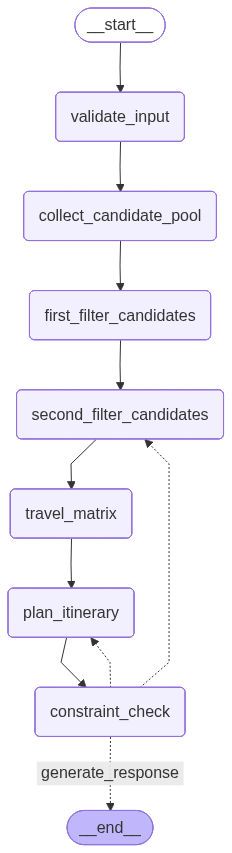

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))